# Reserved Star Catalog from Cell-based Coadds

Select reserved PSF stars from the DM `object` catalog, extract their
images and PSF models from the cell-based coadds.

This notebook loads the DM object catalog for the A360 field, selects
stars that were reserved for PSF validation (not used for PSF modeling),
and retrieves their postage stamps and PSF models from the cell coadds.

## 1. Setup

In [1]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack
from lsst.daf.butler import Butler
from lsst.geom import SpherePoint, Point2D, Point2I, degrees as lsst_degrees
from lsst.skymap import Index2D
from xlens.utils.image import resize_array

## 2. Load DM Object Catalog and Select Reserved Stars (i-band)

In [2]:
# Butler setup
butler_config = "/global/cfs/cdirs/lsst/production/gen3/rubin/DP1/repo/butler.yaml"
anacal_collection = "u/xiangchl/dp1/a360_anacal"
input_collections = [
    anacal_collection,
    "u/mgorsuch/metadetect/a360_extra_cells",
    "u/mgorsuch/metadetect/a360_metadetect",
    "u/mgorsuch/metadetect/a360_coadd",
    "LSSTComCam/DP1",
]
obs_butler = Butler(butler_config, collections=input_collections)
t_skymap = obs_butler.get("skyMap", skymap="lsst_cells_v1")

# Cluster location
cluster_coords = (37.865017, 6.982205)
ra_bcg, dec_bcg = cluster_coords

In [12]:
# Load the DM object catalog (per tract)
# This contains PSF star flags from the DRP pipeline
tract_ids = [10463, 10464, 10704]
dm_tables = []
for tid in tract_ids:
    try:
        cat = obs_butler.get("object", skymap="lsst_cells_v1", tract=tid)
        cat = Table(cat)
        cat["tract"] = tid
        dm_tables.append(cat)
        print(f"Loaded tract {tid}: {len(cat)} objects")
    except Exception as e:
        print(f"No object catalog for tract {tid}: {e}")

dm_catalog = vstack(dm_tables)
print(f"\nTotal DM objects: {len(dm_catalog)}")

Loaded tract 10463: 273931 objects
Loaded tract 10464: 155515 objects
Loaded tract 10704: 89252 objects

Total DM objects: 518698


In [4]:
# Select reserved PSF stars in i-band
# These stars were held out from PSF modeling for validation
reserved = dm_catalog["i_calib_psf_reserved"].astype(bool)
candidate = dm_catalog["i_calib_psf_candidate"].astype(bool)
used = dm_catalog["i_calib_psf_used"].astype(bool)

print(f"PSF candidates: {np.sum(candidate)}")
print(f"PSF used:       {np.sum(used)}")
print(f"PSF reserved:   {np.sum(reserved)}")

# Select reserved stars with good measurements
star_sel = (
    reserved
    & np.isfinite(dm_catalog["i_centroid_x"])
    & np.isfinite(dm_catalog["i_centroid_y"])
    & ~dm_catalog["i_psfFlux_flag"]
)
star_catalog = dm_catalog[star_sel]
print(f"\nReserved stars with good measurements: {len(star_catalog)}")
print(f"  RA range: [{star_catalog['coord_ra'].min():.4f}, {star_catalog['coord_ra'].max():.4f}]")
print(f"  DEC range: [{star_catalog['coord_dec'].min():.4f}, {star_catalog['coord_dec'].max():.4f}]")

PSF candidates: 5690
PSF used:       5091
PSF reserved:   589

Reserved stars with good measurements: 589
  RA range: [36.9739, 38.8175]
  DEC range: [6.0654, 7.9615]


## 3. PSF Properties of Reserved Stars

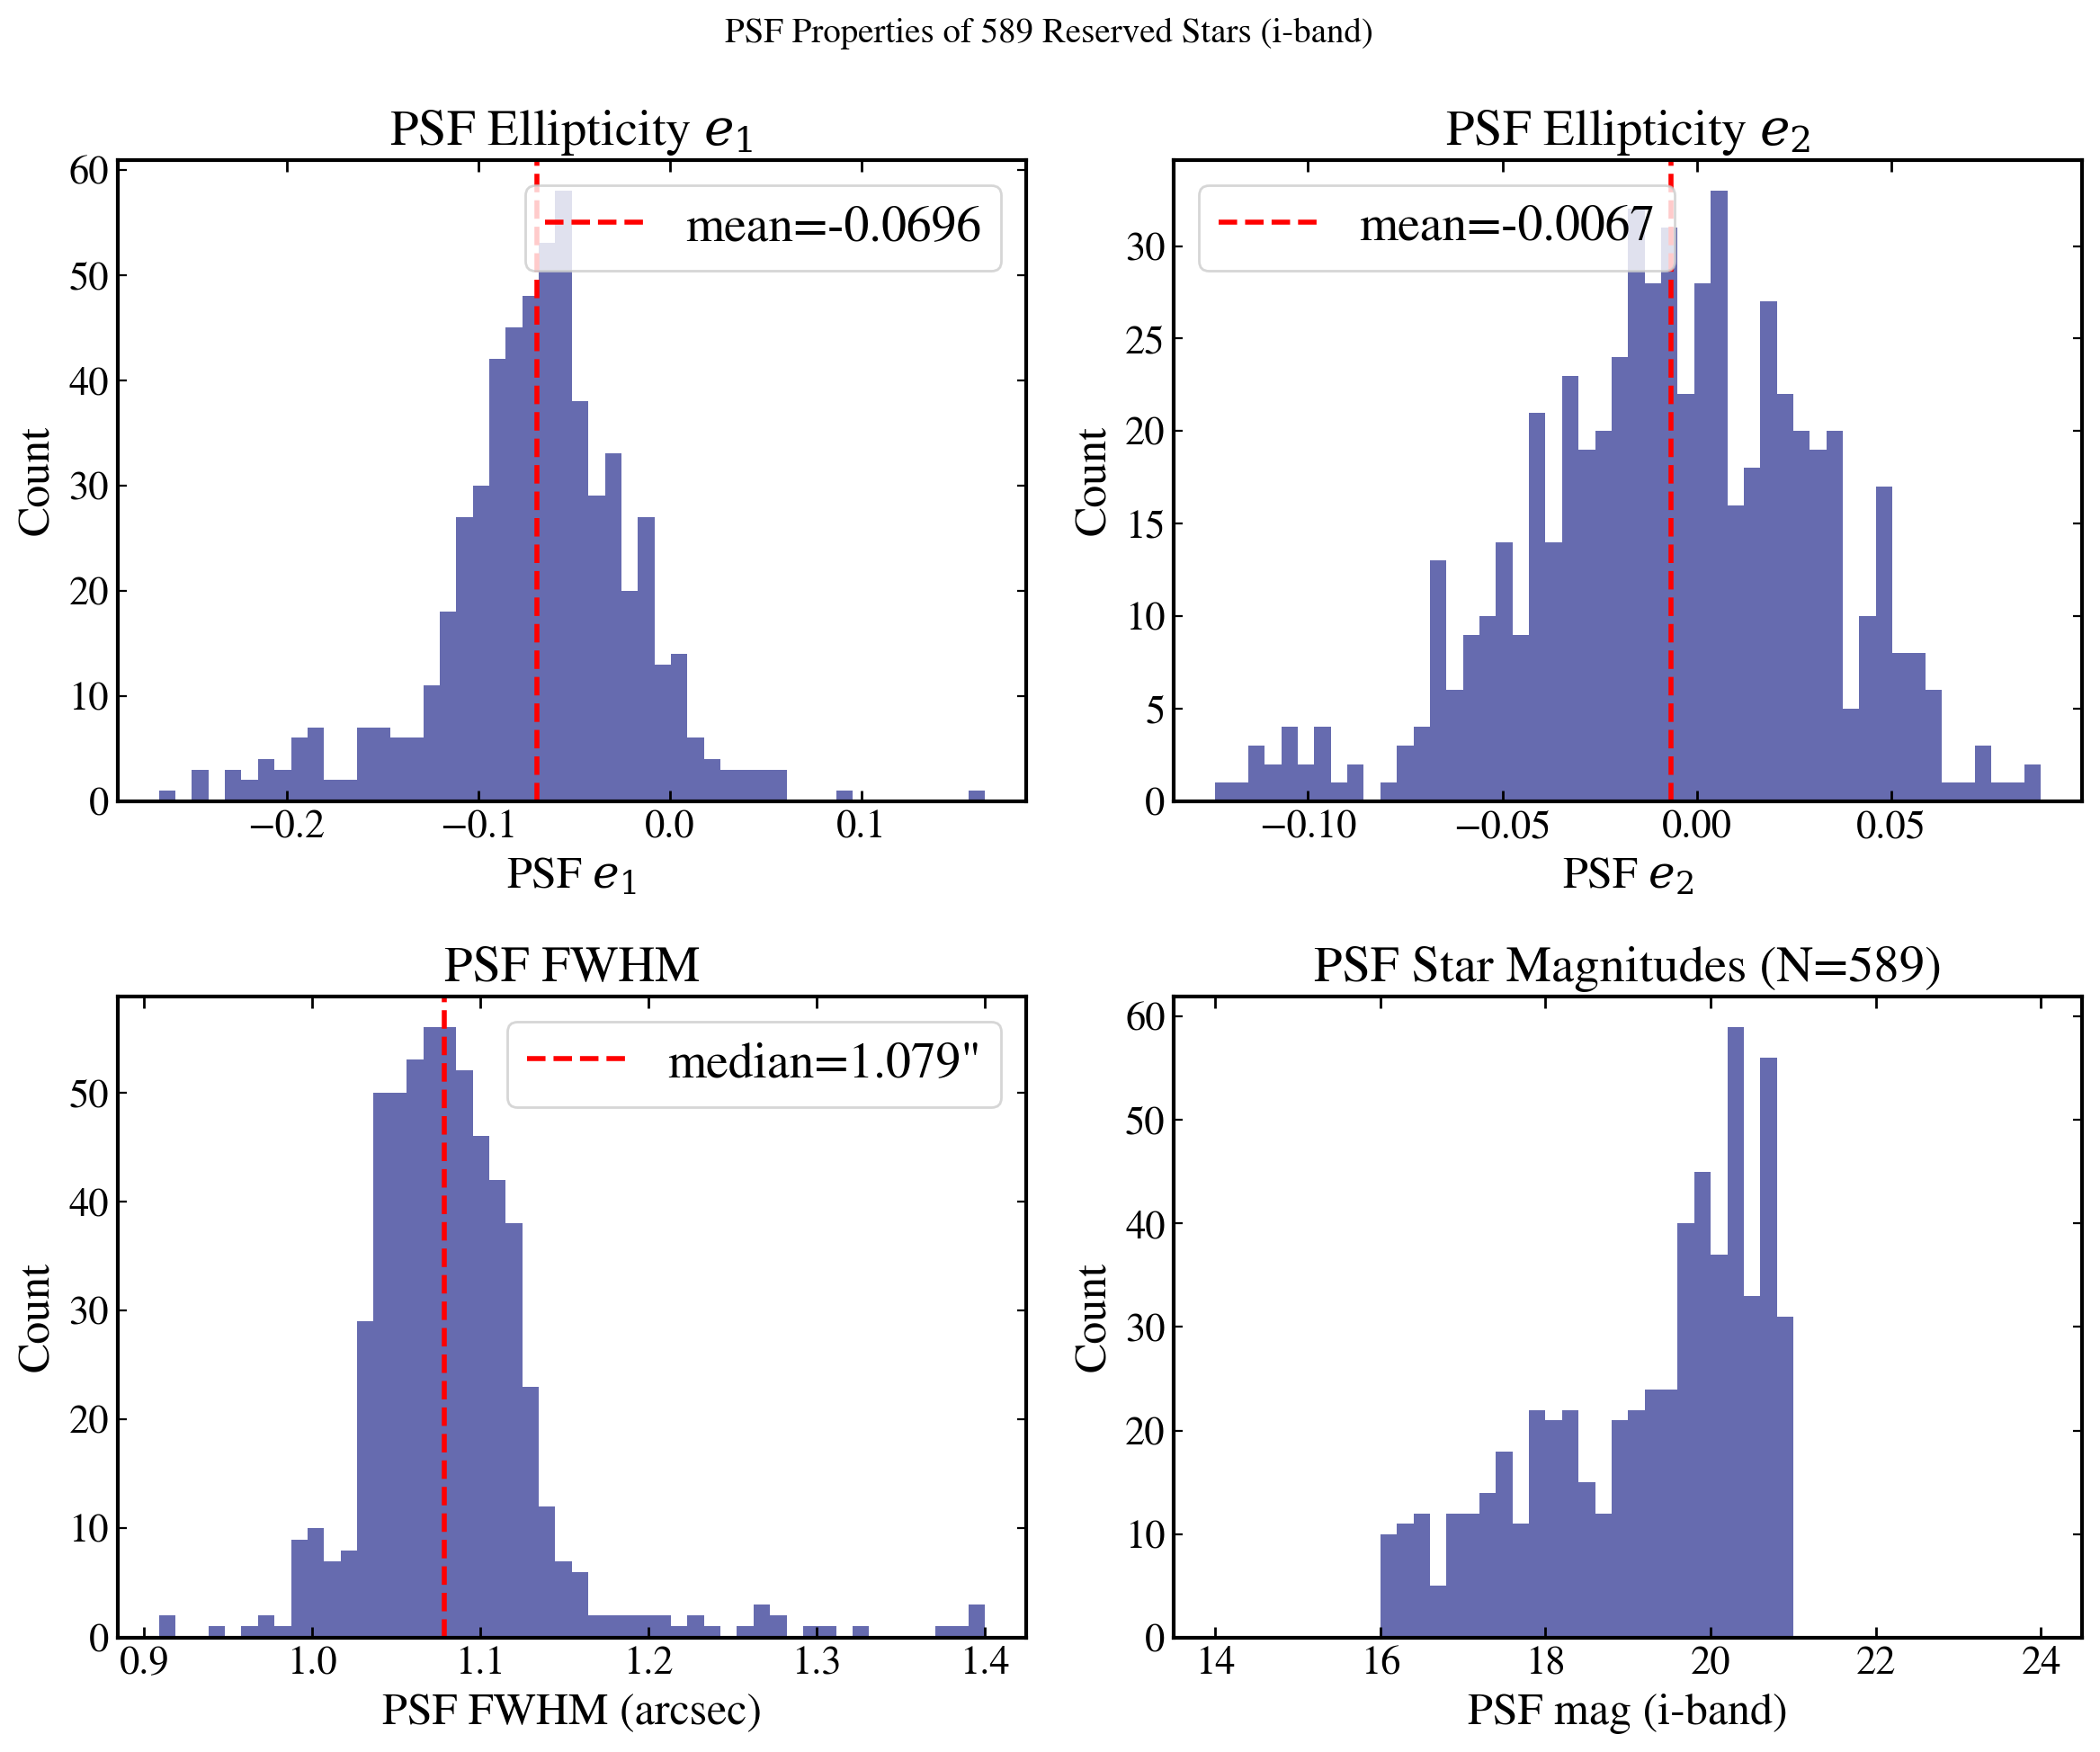

PSF e1: mean=-0.06959, std=0.05244
PSF e2: mean=-0.00667, std=0.03744
PSF FWHM: median=1.079 arcsec, std=0.056 arcsec


In [18]:
# PSF ellipticity and FWHM from adaptive moments (i-band)
psf_mxx = np.array(star_catalog["i_ixxPSF"], dtype=float)
psf_myy = np.array(star_catalog["i_iyyPSF"], dtype=float)
psf_mxy = np.array(star_catalog["i_ixyPSF"], dtype=float)

# PSF ellipticity: e1 = (Ixx - Iyy) / (Ixx + Iyy), e2 = 2*Ixy / (Ixx + Iyy)
e1_psf = (psf_mxx - psf_myy) / (psf_mxx + psf_myy)
e2_psf = 2.0 * psf_mxy / (psf_mxx + psf_myy)

# PSF FWHM from Gaussian moments: FWHM = 2.355 * (Ixx*Iyy - Ixy^2)^(1/4)
det = psf_mxx * psf_myy - psf_mxy**2
pixel_scale = 0.2  # arcsec/pixel
fwhm_psf = 2.355 * det**0.25 * pixel_scale  # in arcsec

# PSF magnitude
psf_flux = np.array(star_catalog["i_psfFlux"], dtype=float)
mag_zero = 31.4
valid_flux = psf_flux > 0
psf_mag = np.full(len(star_catalog), np.nan)
psf_mag[valid_flux] = mag_zero - 2.5 * np.log10(psf_flux[valid_flux])

good = np.isfinite(e1_psf) & np.isfinite(e2_psf) & np.isfinite(fwhm_psf)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

ax = axes[0, 0]
ax.hist(e1_psf[good], bins=50, alpha=0.7)
ax.axvline(np.mean(e1_psf[good]), color='r', ls='--',
           label=f"mean={np.mean(e1_psf[good]):.4f}")
ax.set_xlabel(r"PSF $e_1$"); ax.set_ylabel("Count")
ax.set_title("PSF Ellipticity $e_1$"); ax.legend()

ax = axes[0, 1]
ax.hist(e2_psf[good], bins=50, alpha=0.7)
ax.axvline(np.mean(e2_psf[good]), color='r', ls='--',
           label=f"mean={np.mean(e2_psf[good]):.4f}")
ax.set_xlabel(r"PSF $e_2$"); ax.set_ylabel("Count")
ax.set_title("PSF Ellipticity $e_2$"); ax.legend()

ax = axes[1, 0]
ax.hist(fwhm_psf[good], bins=50, alpha=0.7)
ax.axvline(np.median(fwhm_psf[good]), color='r', ls='--',
           label=f'median={np.median(fwhm_psf[good]):.3f}"')
ax.set_xlabel('PSF FWHM (arcsec)'); ax.set_ylabel("Count")
ax.set_title("PSF FWHM"); ax.legend()

ax = axes[1, 1]
ax.hist(psf_mag[valid_flux], bins=50, range=(14, 24), alpha=0.7)
ax.set_xlabel("PSF mag (i-band)"); ax.set_ylabel("Count")
ax.set_title(f"PSF Star Magnitudes (N={np.sum(valid_flux)})")

plt.suptitle(f"PSF Properties of {np.sum(good)} Reserved Stars (i-band)", fontsize=14)
plt.tight_layout(); plt.show()

print(f"PSF e1: mean={np.mean(e1_psf[good]):.5f}, std={np.std(e1_psf[good]):.5f}")
print(f"PSF e2: mean={np.mean(e2_psf[good]):.5f}, std={np.std(e2_psf[good]):.5f}")
print(f"PSF FWHM: median={np.median(fwhm_psf[good]):.3f} arcsec, "
      f"std={np.std(fwhm_psf[good]):.3f} arcsec")

## 3. Plot Reserved Star Locations

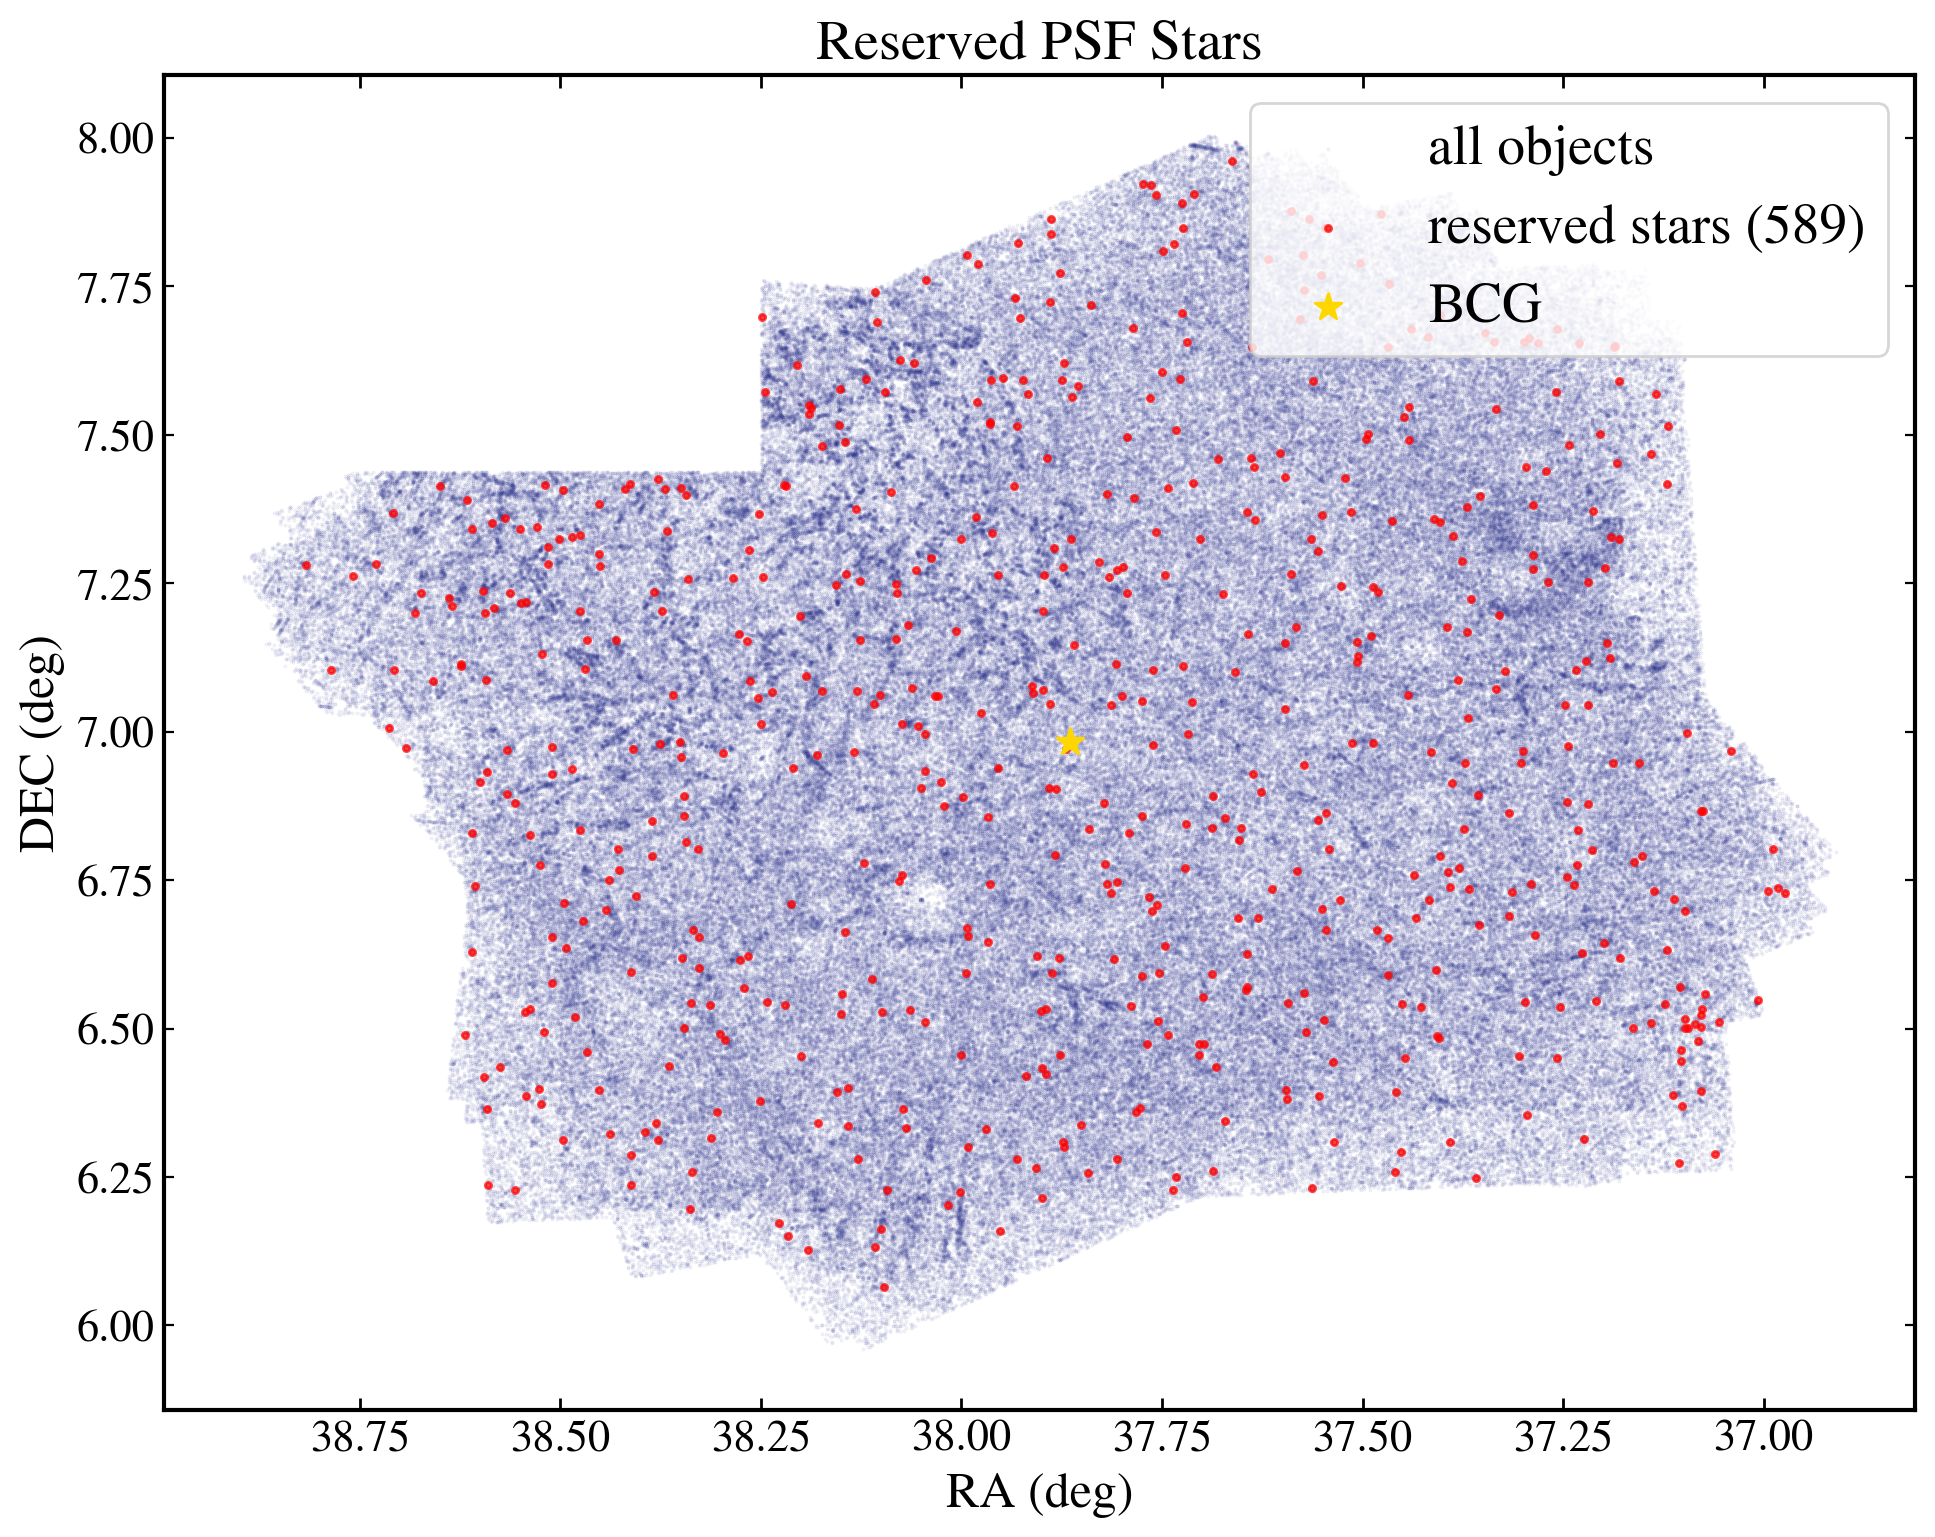

In [5]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(dm_catalog["coord_ra"], dm_catalog["coord_dec"], s=0.1, alpha=0.1, label="all objects")
ax.scatter(star_catalog["coord_ra"], star_catalog["coord_dec"], s=5, c='red', alpha=0.7,
           label=f"reserved stars ({len(star_catalog)})")
ax.scatter(ra_bcg, dec_bcg, s=100, c='gold', marker='*', zorder=10, label='BCG')
ax.set_xlabel("RA (deg)"); ax.set_ylabel("DEC (deg)")
ax.set_title("Reserved PSF Stars")
ax.legend(loc='upper right')
ax.invert_xaxis()
plt.tight_layout(); plt.show()

## 4. Extract Star Images and PSF Models from Cell Coadds

In [ ]:
def get_star_stamps_from_patch(
    butler, star_catalog, tract, patch,
    skymap_name, band="i", stamp_size=41
):
    """Extract star postage stamps and PSF models from individual cells.

    Only includes stars whose centroid falls within the cell inner region.
    Star images are extracted from the cell outer region (full 250x250)
    and subpixel-shifted to center the star. PSF is taken from the cell's
    psf_image. This matches the approach in build_systematics.py.

    Parameters
    ----------
    butler : Butler
    star_catalog : Table
        DM object catalog with {band}_centroid_x/y columns.
    tract, patch : int
    skymap_name : str
    band : str
    stamp_size : int
        Output stamp size (should be odd).

    Returns
    -------
    stamps : list of (star_stamp, psf_stamp, ra, dec)
    """
    from xlens.utils.image import resize_array, subpixel_shift

    refs = list(butler.registry.queryDatasets(
        "deep_coadd_cell_predetection",
        where=f"skymap='{skymap_name}' AND tract={tract} AND patch={patch} AND band='{band}'",
    ))
    if not refs:
        return []
    coadd = butler.get(refs[0])

    half = stamp_size // 2
    stamps = []
    xn = f"{band}_centroid_x"
    yn = f"{band}_centroid_y"

    for cell_id, cell in coadd.cells.items():
        inner_bbox = cell.inner.bbox
        outer_bbox = cell.outer.bbox
        img = cell.outer.image.array

        # Select stars whose centroid is in this cell's inner region
        cx = star_catalog[xn]
        cy = star_catalog[yn]
        in_inner = (
            np.isfinite(cx) & np.isfinite(cy)
            & (cx >= inner_bbox.getMinX()) & (cx <= inner_bbox.getMaxX())
            & (cy >= inner_bbox.getMinY()) & (cy <= inner_bbox.getMaxY())
        )
        if not np.any(in_inner):
            continue

        # PSF from cell psf_image
        psf_img = cell.psf_image.array
        psf_stamp = resize_array(psf_img, (stamp_size, stamp_size)).astype(np.float64)
        psf_stamp /= np.sum(psf_stamp)

        for row in star_catalog[in_inner]:
            sx = float(row[xn])
            sy = float(row[yn])

            # Local pixel in outer region
            lx = int(sx) - outer_bbox.getMinX()
            ly = int(sy) - outer_bbox.getMinY()

            # Check stamp fits within outer region
            if (ly - half < 0 or ly + half + 1 > img.shape[0] or
                lx - half < 0 or lx + half + 1 > img.shape[1]):
                continue

            star_stamp = img[ly - half: ly + half + 1,
                             lx - half: lx + half + 1].copy().astype(np.float64)

            # Subpixel shift to center the star
            offset_x = sx - int(sx)
            offset_y = sy - int(sy)
            star_stamp = subpixel_shift(star_stamp, -offset_x, -offset_y)

            ra = float(row["coord_ra"])
            dec = float(row["coord_dec"])
            stamps.append((star_stamp, psf_stamp, ra, dec))

    del coadd
    return stamps

In [8]:
# Extract stamps for reserved stars from all available patches
stamp_size = 41
star_stamps = []
psf_stamps = []
star_ras = []
star_decs = []

skymap_name = "lsst_cells_v1"
tract_ids = sorted(set(star_catalog["tract"]))

tid = 10464
tract_stars = star_catalog[star_catalog["tract"] == tid]

# Find patches with cell coadds
refs = list(obs_butler.registry.queryDatasets(
    "deep_coadd_cell_predetection",
    where=f"skymap='{skymap_name}' AND tract={tid} AND band='i'",
))
available_patches = sorted(set(r.dataId["patch"] for r in refs))
print(f"Tract {tid}: {len(tract_stars)} stars, {len(available_patches)} patches")

pid = available_patches[0]
stamps = get_star_stamps_from_patch(
    obs_butler, tract_stars, tid, pid,
    skymap_name, band="i", stamp_size=stamp_size,
)
for star_img, psf_img, ra, dec in stamps:
    star_stamps.append(star_img)
    psf_stamps.append(psf_img)
    star_ras.append(ra)
    star_decs.append(dec)

Tract 10464: 179 stars, 21 patches


In [11]:
star_stamps[0].shape

(41, 41)

## 5. Visualize Star Images vs PSF Models

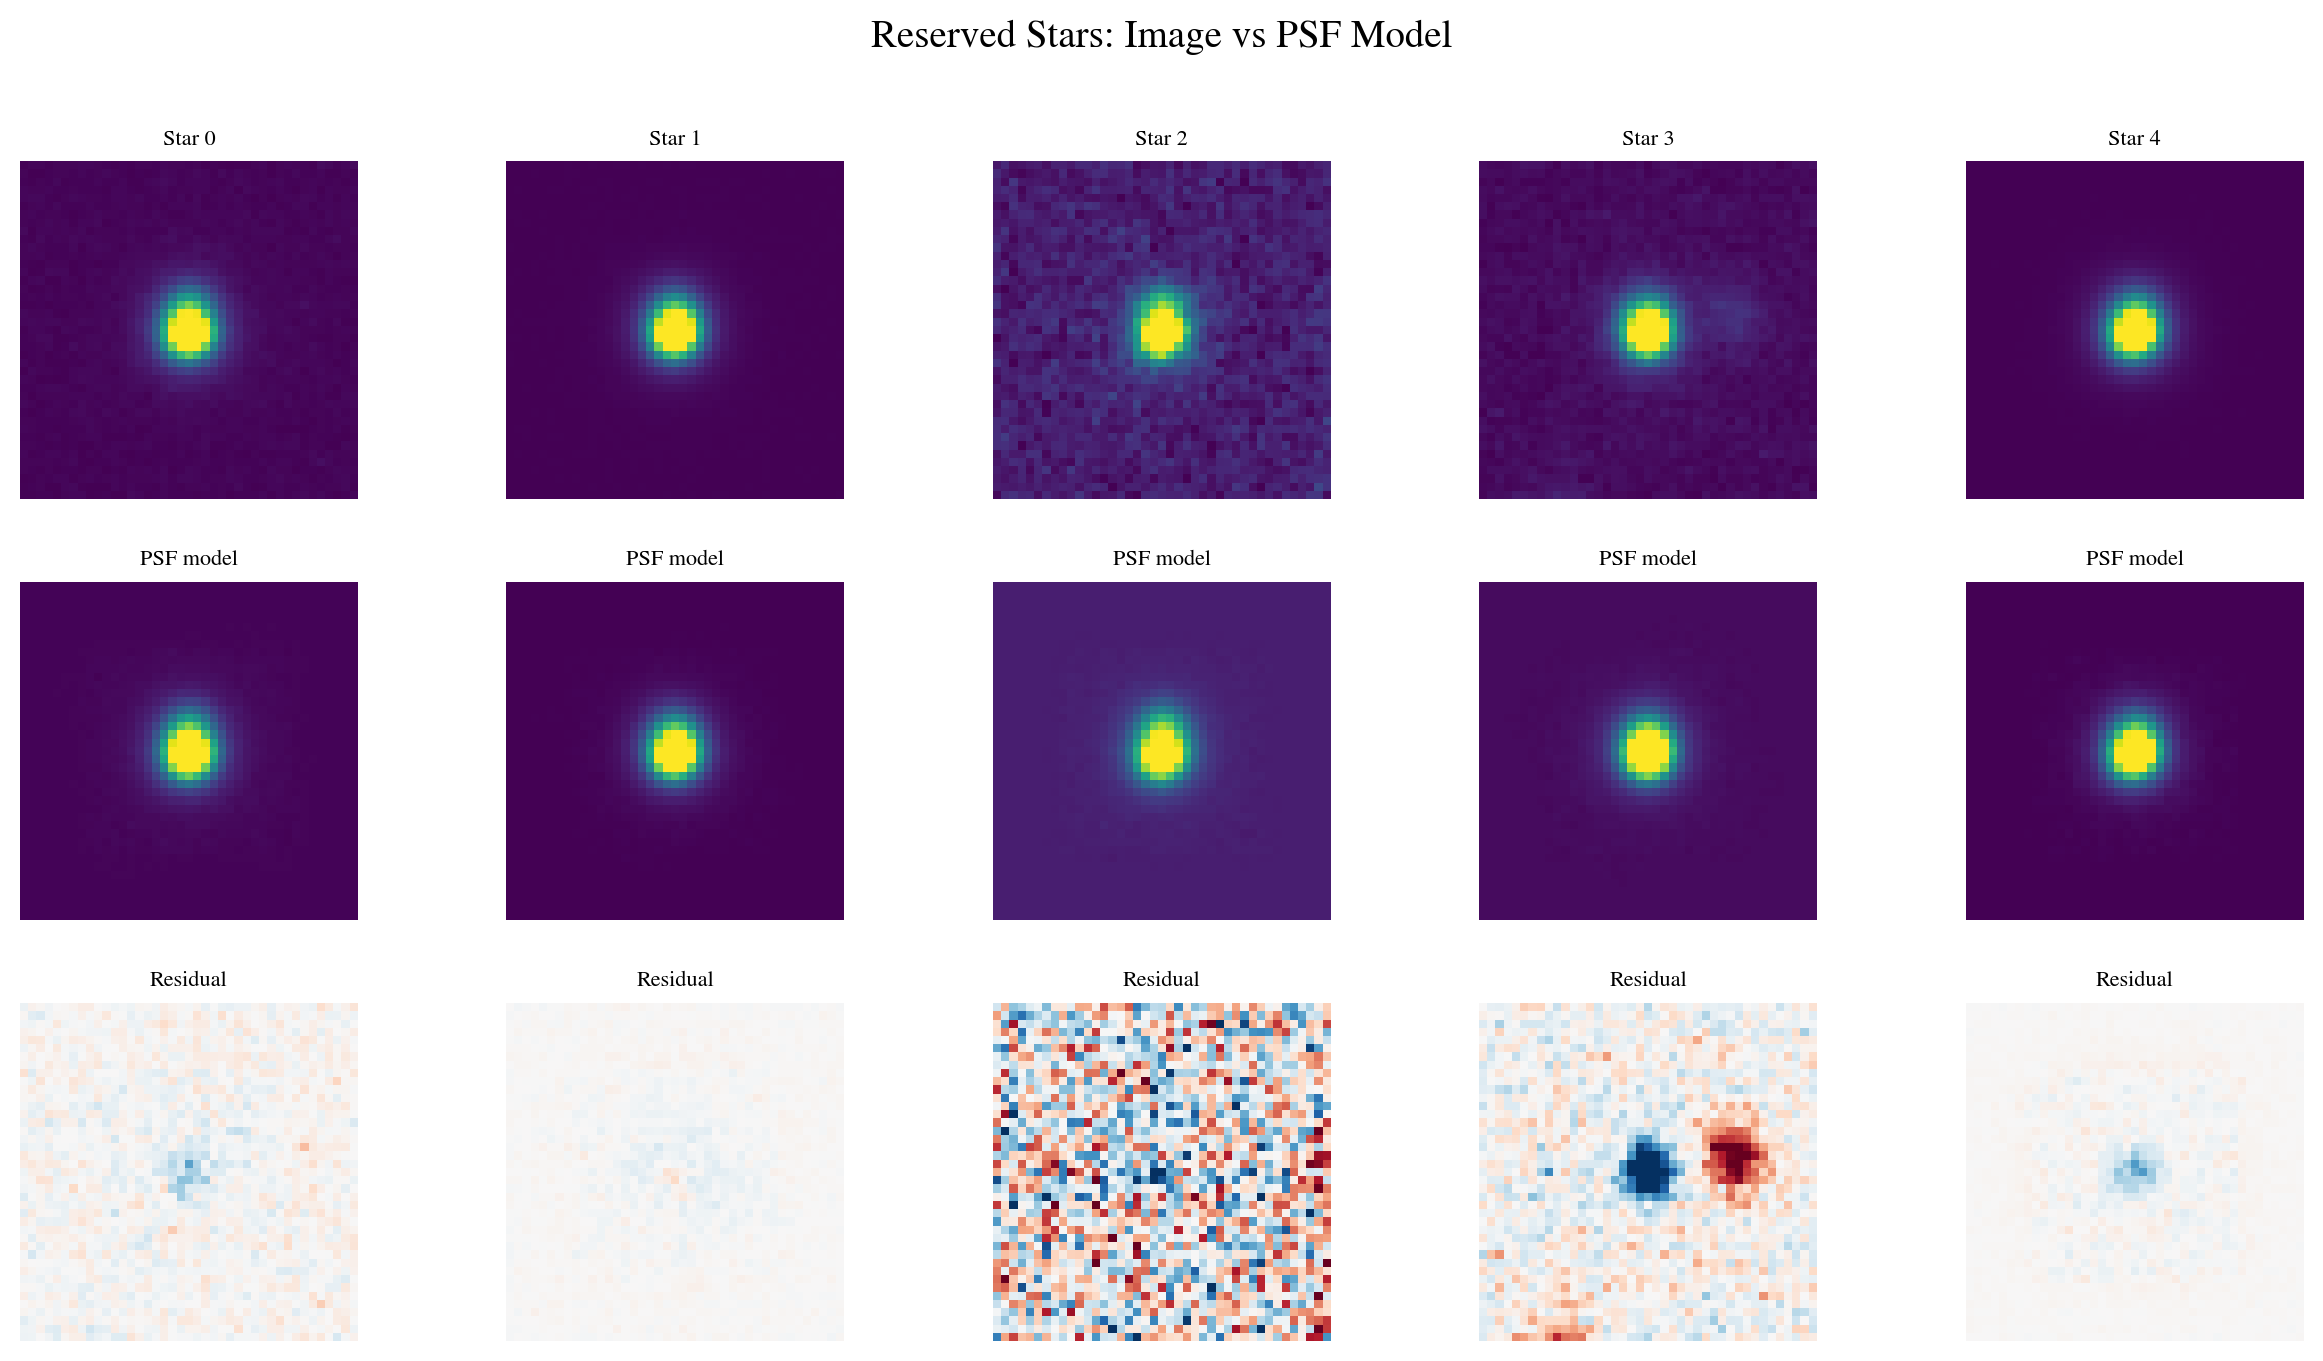

In [9]:
n_show = min(9, len(star_stamps))
if n_show == 0:
    print("No star stamps extracted")
else:
    fig, axes = plt.subplots(3, n_show, figsize=(2.5 * n_show, 7))
    if n_show == 1:
        axes = axes[:, np.newaxis]

    for i in range(n_show):
        star = star_stamps[i]
        psf = psf_stamps[i]
        psf_scaled = psf * np.sum(star) / np.sum(psf)
        residual = star - psf_scaled

        vmin = np.percentile(star, 1)
        vmax = np.percentile(star, 99)

        axes[0, i].imshow(star, origin="lower", vmin=vmin, vmax=vmax, cmap="viridis")
        axes[0, i].set_title(f"Star {i}", fontsize=8)
        axes[0, i].axis("off")

        axes[1, i].imshow(psf_scaled, origin="lower", vmin=vmin, vmax=vmax, cmap="viridis")
        axes[1, i].set_title("PSF model", fontsize=8)
        axes[1, i].axis("off")

        axes[2, i].imshow(residual, origin="lower", cmap="RdBu_r",
                          vmin=-vmax * 0.1, vmax=vmax * 0.1)
        axes[2, i].set_title("Residual", fontsize=8)
        axes[2, i].axis("off")

    axes[0, 0].set_ylabel("Star"); axes[1, 0].set_ylabel("PSF"); axes[2, 0].set_ylabel("Residual")
    plt.suptitle("Reserved Stars: Image vs PSF Model", fontsize=14)
    plt.tight_layout(); plt.show()

In [10]:
# Summary statistics of residuals
print("Fractional residual (|residual| / star_flux):")
for i in range(len(star_stamps)):
    star = star_stamps[i]
    psf = psf_stamps[i]
    psf_scaled = psf * np.sum(star) / np.sum(psf)
    frac_resid = np.sum(np.abs(star - psf_scaled)) / np.sum(np.abs(star))
    print(f"  Star {i}: {frac_resid:.4f}")

Fractional residual (|residual| / star_flux):
  Star 0: 0.1293
  Star 1: 0.0522
  Star 2: 0.5026
  Star 3: 0.3316
  Star 4: 0.0681
